# Pubmat Checker — Metrics & Evaluation Notebook

This notebook measures how accurate and how fast the pubmat checker is. Testing set is manually labeled according to the guidelines, this serves to check whether the checker's audit (prediction) agrees with the label (actual).


## Imports

In [1]:
import cv2
import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from ultralytics import YOLO

from checker import generate_report




## Configuration


In [3]:
TEST_SET_DIR = 'test_set/images/'           # folder containing test images
LABELS_FILE  = 'test_set/labels.json'
MODEL_PATH   = '../training/runs/detect/tuned_model_v2/weights/best.pt'

model = YOLO(MODEL_PATH)
print(f'Model loaded: {MODEL_PATH}')

Model loaded: ../training/runs/detect/tuned_model_v2/weights/best.pt


## Test Set

### Test Set Labeling Guidelines

Each labels file is a JSON array where each entry corresponds to one test image.

Manually assign ground_truth values. For all checks: true = the pubmat passes based on guidelines, false = the pubmat fails

**Check Definitions**

- logo_nyc and logo_bp: true if logo is present AND correct, false if missing OR incorrect
- logo_sk or logo_yorp: only add them in if the post should have SK and/or YORP logos
- logo_order: true if correct, false if incorrect; (correct order must be NYC > (SK/YORP) > BP)
- watermark: true if all socmed handles are present as wm, false if not 
- pubmat_quality: true if image is sharp, not blurry, has good contrast, and resolution (at least 720px x 720px), false if blurry, low contrast, or low res
- readability: true if text is clear and readable, false if text too small, poor contrast with background, or font too illegible
- sgd: true if SGD appears in the document, false if not. (for advisory/resolution)
- spelling : true if no spelling errors found, false if misspelled words detected
- photo_quality: true if photo is at least 1080 x 1080px and in color, false if too small, too dark/bright, desaturated or gray

**Note**: spelling and photo_quality do not cause an overall fail result on their own. all other checks must pass to receive an overall PASS result.

**Example labels.json**

```json
[
  {
    "image": "pub_001.jpg",
    "post_type": "news",
    "collaborators": [],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_order":     true,
      "watermark":      false,
      "pubmat_quality": true,
      "readability":    true,
      "spelling":       true,
    },
    "notes": "No watermark"
  },
  {
    "image": "pub_003.jpg",
    "post_type": "photo",
    "collaborators": [],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_order":     true,
      "pubmat_quality": true,
      "readability":    true,
      "photo_quality":  false
    },
    "notes": "Photo is too dark."
  }
]
```

Add brief explanation for why the image fails in the "notes" section.

### Load and inspect the labels file

Read labels and counts instances

In [5]:
with open(LABELS_FILE) as f:
    test_set = json.load(f)

print(f'Test set loaded: {len(test_set)} images\n')
print('Post type breakdown:')
type_counts = Counter(s['post_type'] for s in test_set)
for ptype, count in sorted(type_counts.items()):
    print(f'  {ptype:<14} {count} images')

Test set loaded: 105 images

Post type breakdown:
  advisory       3 images
  hiring         2 images
  holiday        14 images
  news           17 images
  other          43 images
  photo          24 images
  quote          2 images



## Prediction Extractor

This function translates the nested audit output into the same flat key format as ground truth so that comparisons work directly.

Key mappings:
- `audit['logos']['details']['logos']` list → `predicted['logo_nyc']`, `predicted['logo_bp']`, etc.
- `audit['logo_order']['pass']` → `predicted['logo_order']`
- `audit['watermark']['pass']` → `predicted['watermark']`
- `audit['readability']['pass']` → `predicted['readability']`
- `audit['spelling']['pass']` → `predicted['spelling']`
- `audit['sgd']['pass']` → `predicted['sgd']`
- `audit['pubmat_quality']['pass']` → `predicted['pubmat_quality']`
- `audit['photo_quality']['pass']` → `predicted['photo_quality']`


In [6]:
def extract_predictions(audit: dict) -> dict:
    """
    Flatten the audit dict into the same key format as ground_truth.
    Returns a dict of {check_name: bool}.
    """
    preds = {}

    # Logo compliance — one key per logo that was checked
    # audit['logos']['details']['logos'] is a list of per-logo dicts
    for logo_entry in audit.get('logos', {}).get('details', {}).get('logos', []):
        key = f"logo_{logo_entry['logo'].lower()}"
        preds[key] = logo_entry['pass']

    # Checks that always run
    if 'logo_order' in audit:
        preds['logo_order'] = audit['logo_order']['pass']
    if 'pubmat_quality' in audit:
        preds['pubmat_quality'] = audit['pubmat_quality']['pass']

    # Conditional checks — present only when applicable to the post type
    for key in ('readability', 'watermark', 'sgd', 'spelling', 'photo_quality'):
        if key in audit:
            preds[key] = audit[key]['pass']

    return preds

## Run the Full Test Set

This is the main processing loop. For every image in the test set it:
1. Reads the image from disk
2. Calls `generate_report()` which runs YOLO + OCR + all checks internally
3. Records how long the whole call took
4. Extracts predictions using `extract_predictions()`
5. Stores ground truth, predictions, and timing together


In [7]:
results = []
errors  = []

for sample in test_set:
    img_path = os.path.join(TEST_SET_DIR, sample['image'])

    if not os.path.exists(img_path):
        errors.append({'image': sample['image'], 'error': 'File does not exist'})
        continue

    image = cv2.imread(img_path)
    if image is None:
        errors.append({'image': sample['image'], 'error': 'Failed to load image (corrupted or unsupported)'})
        continue

    try:
        t_start = time.perf_counter()

        audit, _ = generate_report(
            image,
            logo_model=model,
            post_type=sample['post_type'],
            collaborators=sample.get('collaborators', []),
        )

        elapsed = time.perf_counter() - t_start

        results.append({
            'image':        sample['image'],
            'post_type':    sample['post_type'],
            'ground_truth': sample['ground_truth'],
            'predicted':    extract_predictions(audit),
            'audit_raw':    audit,
            'elapsed_s':    round(elapsed, 3),
            'notes':        sample.get('notes', ''),
        })

    except Exception as e:
        import traceback
        errors.append({'image': sample['image'], 'error': str(e), 'traceback': traceback.format_exc()})

print(f'Processed : {len(results)} images')
print(f'Errors    : {len(errors)}')
if errors:
    for e in errors:
        print(f'  {e["image"]}: {e["error"]}')



0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Incorrect, 61.1ms
Speed: 23.8ms preprocess, 61.1ms inference, 20.8ms postprocess per image at shape (1, 3, 800, 640)

0: 544x800 1 NYC_Correct, 1 BP_Correct, 196.4ms
Speed: 7.8ms preprocess, 196.4ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 800)

0: 800x640 1 NYC_Correct, 1 SK_Correct, 1 YORP_Correct, 137.0ms
Speed: 6.1ms preprocess, 137.0ms inference, 3.3ms postprocess per image at shape (1, 3, 800, 640)

0: 800x640 2 NYC_Corrects, 2 BP_Corrects, 364.3ms
Speed: 8.6ms preprocess, 364.3ms inference, 1.9ms postprocess per image at shape (1, 3, 800, 640)

0: 480x800 1 NYC_Correct, 1 BP_Correct, 264.9ms
Speed: 11.4ms preprocess, 264.9ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 1 NYC_Correct, 1 BP_Correct, 111.6ms
Speed: 4.7ms preprocess, 111.6ms inference, 5.1ms postprocess per image at shape (1, 3, 480, 800)

0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 124.8ms
Speed: 8.6ms preproc


## Metrics

True Positive (TP): Checker correctly said PASS. Image genuinely passes. \
True Negative (TN): Checker correctly said FAIL. Image genuinely fails. \
False Positive (FP): Checker said PASS but image actually fails. The checker missed a real problem. \
False Negative (FN): Checker said FAIL but image actually passes. The checker flagged something that is fine.


**Precision = TP / (TP + FP)**

**Recall = TP / (TP + FN)**

**F1 Score = 2 * (Precision * Recall) / (Precision + Recall)**



In [8]:
# Derive per-check severity level from POST_TYPE_RULES
# A check is 'warning' if it appears as warning in ANY post type rule.
WARNING_CHECKS = {'spelling', 'photo_quality'}  # checks with level='warning' in checker.py

# Group y_true and y_pred by check name across all images
by_check = defaultdict(lambda: {'y_true': [], 'y_pred': [], 'images': []})

for r in results:
    for check, true_val in r['ground_truth'].items():
        if check in r['predicted']:
            by_check[check]['y_true'].append(int(true_val))
            by_check[check]['y_pred'].append(int(r['predicted'][check]))
            by_check[check]['images'].append(r['image'])

rows = []
for check, data in sorted(by_check.items()):
    yt, yp = data['y_true'], data['y_pred']
    n   = len(yt)
    p   = precision_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    f1  = f1_score(yt, yp, zero_division=0)
    acc = sum(t == p_ for t, p_ in zip(yt, yp)) / n
    level = 'warning' if check in WARNING_CHECKS else 'error'
    rows.append({'check': check, 'level': level, 'n': n,
                 'precision': p, 'recall': rec, 'f1': f1, 'accuracy': acc})

df_metrics = pd.DataFrame(rows).set_index('check').sort_values('f1')

display(df_metrics.style
    .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}', 'accuracy': '{:.3f}'})
    .background_gradient(subset=['precision', 'recall', 'f1', 'accuracy'], cmap='RdYlGn', vmin=0, vmax=1)
)


,level,n,precision,recall,f1,accuracy
check,,,,,,
spelling,warning,3,0.000,0.000,0.000,0.333
logo_sk,error,14,0.818,0.750,0.783,0.643
logo_yorp,error,11,0.800,0.889,0.842,0.727
watermark,error,67,0.974,0.771,0.860,0.821
photo_quality,warning,24,0.900,0.947,0.923,0.875
logo_order,error,100,0.976,0.910,0.942,0.900
pubmat_quality,error,100,1.000,0.928,0.963,0.930
logo_bp,error,100,0.968,0.989,0.978,0.960
logo_nyc,error,100,1.000,0.968,0.984,0.970


### Bar Chart — Precision vs Recall vs F1 per Check

The same numbers visualised as grouped bars. The red dashed line at 0.90 is a rough target — any check below it is worth investigating. Checks where precision and recall are far apart (one bar much taller than the other) indicate the check is biased in one direction.

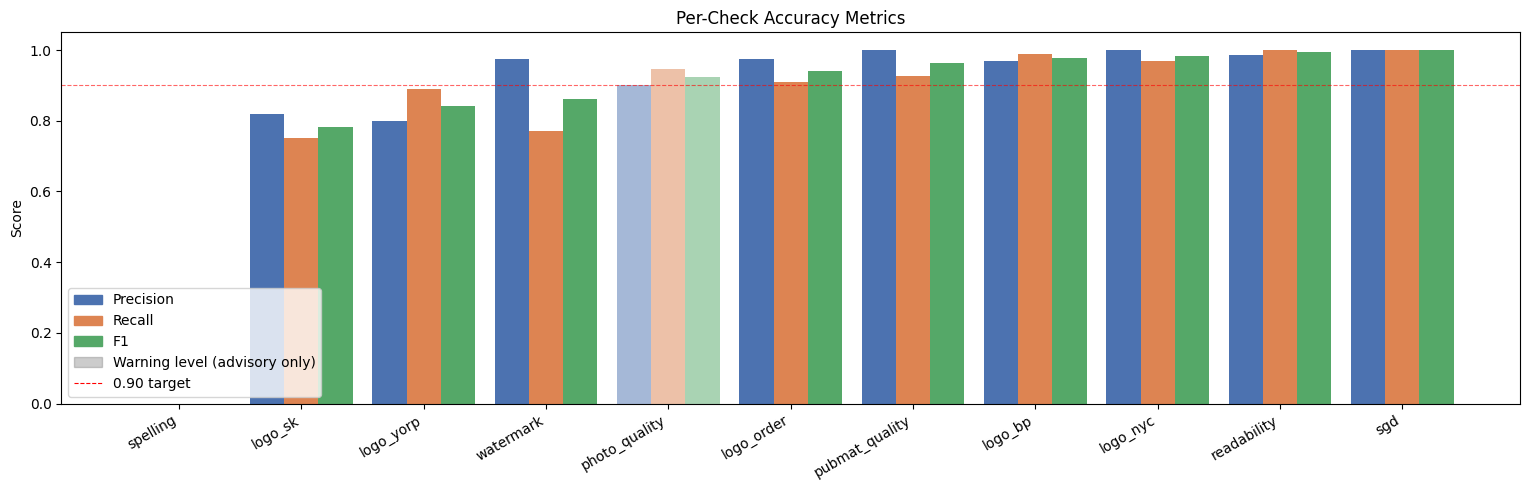

In [9]:
checks = df_metrics.index.tolist()
x = np.arange(len(checks))
w = 0.28

fig, ax = plt.subplots(figsize=(max(12, len(checks) * 1.4), 5))

for i, (check, row) in enumerate(df_metrics.iterrows()):
    alpha = 0.5 if row['level'] == 'warning' else 1.0
    ax.bar(i - w, row['precision'], w, color='#4C72B0', alpha=alpha)
    ax.bar(i,     row['recall'],    w, color='#DD8452', alpha=alpha)
    ax.bar(i + w, row['f1'],        w, color='#55A868', alpha=alpha)

ax.set_xticks(x)
ax.set_xticklabels(checks, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='0.90 target')
ax.set_title('Per-Check Accuracy Metrics')
ax.set_ylabel('Score')

legend_handles = [
    mpatches.Patch(color='#4C72B0', label='Precision'),
    mpatches.Patch(color='#DD8452', label='Recall'),
    mpatches.Patch(color='#55A868', label='F1'),
    mpatches.Patch(color='grey', alpha=0.4, label='Warning level (advisory only)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=0.8, label='0.90 target'),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()


## Confusion Matrices

A confusion matrix shows the four outcome types (TP, TN, FP, FN) as a 2×2 grid for each check.


|                |Predicted FAIL |   Predicted PASS |
| -- | -- | ---|
|Actual FAIL     |  TN            |   FP |
|Actual PASS     |  FN           |    TP |


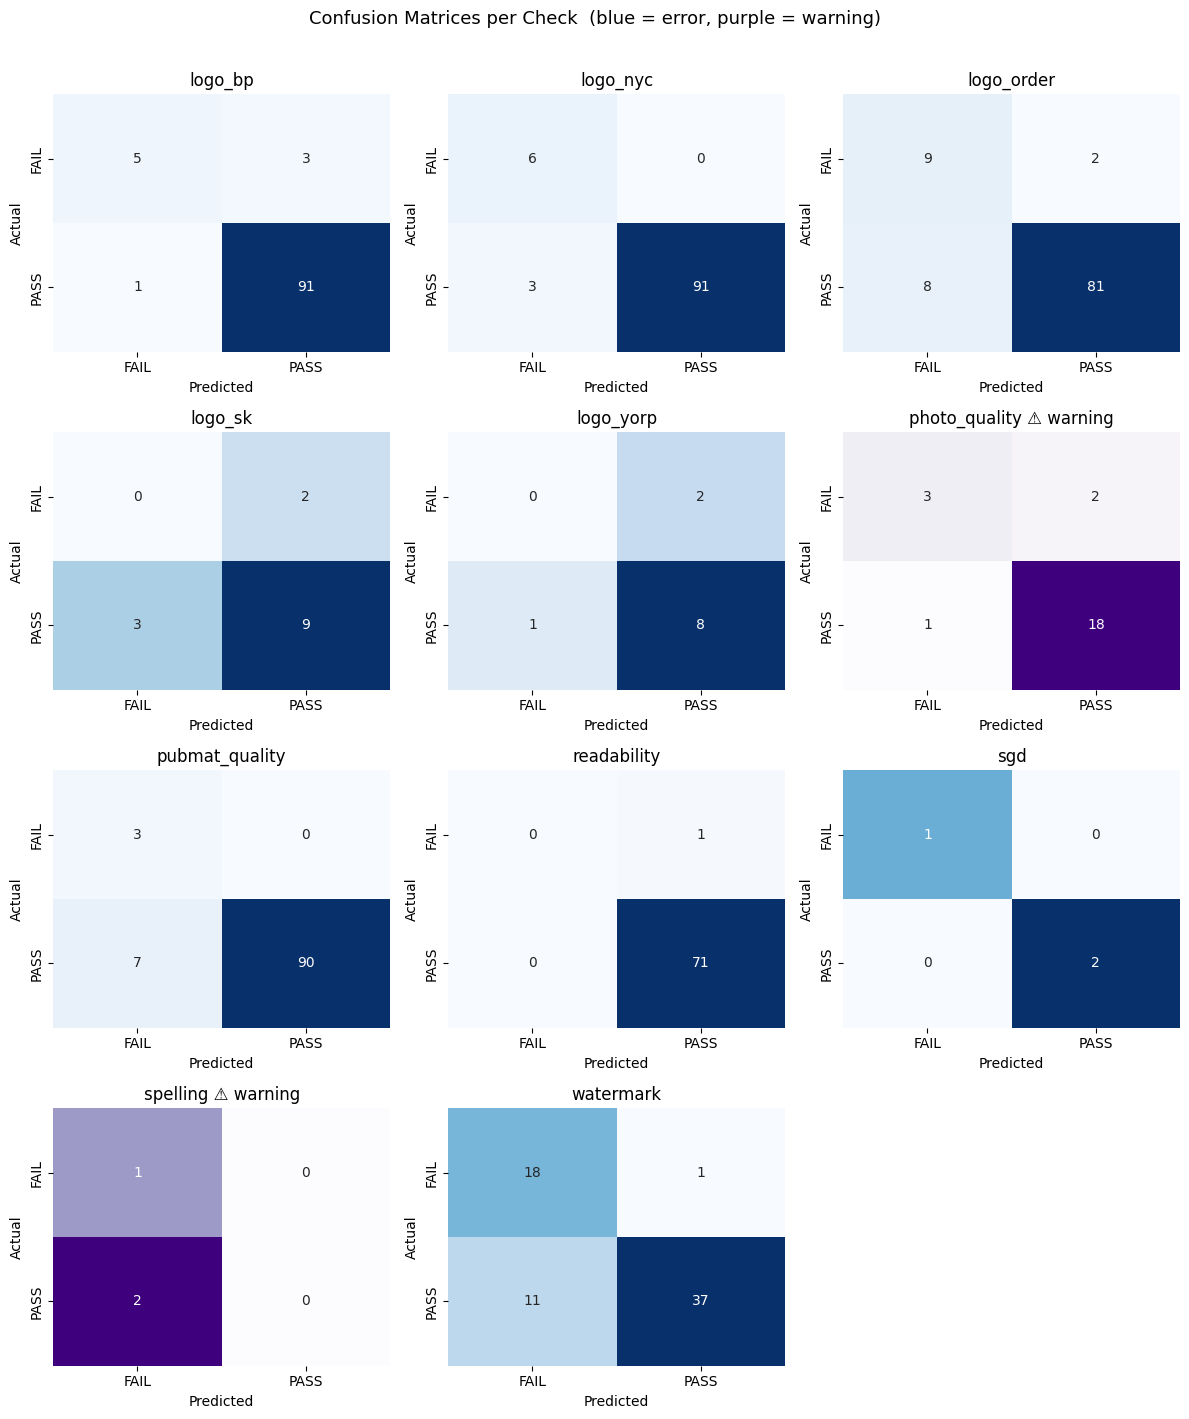

In [10]:
n_checks  = len(by_check)
cols_grid = 3
rows_grid = (n_checks + cols_grid - 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(cols_grid * 4, rows_grid * 3.5))
axes = axes.flatten()

for i, (check, data) in enumerate(sorted(by_check.items())):
    level = 'warning' if check in WARNING_CHECKS else 'error'
    cmap  = 'Purples' if level == 'warning' else 'Blues'
    cm = confusion_matrix(data['y_true'], data['y_pred'], labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=axes[i],
        cmap=cmap, cbar=False,
        xticklabels=['FAIL', 'PASS'],
        yticklabels=['FAIL', 'PASS'],
    )
    title_suffix = ' ⚠ warning' if level == 'warning' else ''
    axes[i].set_title(f'{check}{title_suffix}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices per Check  (blue = error, purple = warning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



## Full Classification Reports

sklearn's `classification_report` prints a detailed breakdown per check including per-class precision, recall, and F1 for both the FAIL class and the PASS class, plus support (how many samples of each class exist).

- The **FAIL class** metrics tell you: when the checker flags a failure, how accurate is that flag?
- The **PASS class** metrics tell you: when the checker clears something, how confident should you be?
- Checks marked `⚠ warning` are advisory — they do **not** cause an overall FAIL.



In [11]:
for check, data in sorted(by_check.items()):
    level_tag = ' [warning]' if check in WARNING_CHECKS else ' [error]'
    print(f'\n══ {check}{level_tag} (n={len(data["y_true"])}) ══')
    print(classification_report(
        data['y_true'], data['y_pred'],
        labels=[0, 1],
        target_names=['FAIL', 'PASS'],
        zero_division=0,
    ))



══ logo_bp [error] (n=100) ══
              precision    recall  f1-score   support

        FAIL       0.83      0.62      0.71         8
        PASS       0.97      0.99      0.98        92

    accuracy                           0.96       100
   macro avg       0.90      0.81      0.85       100
weighted avg       0.96      0.96      0.96       100


══ logo_nyc [error] (n=100) ══
              precision    recall  f1-score   support

        FAIL       0.67      1.00      0.80         6
        PASS       1.00      0.97      0.98        94

    accuracy                           0.97       100
   macro avg       0.83      0.98      0.89       100
weighted avg       0.98      0.97      0.97       100


══ logo_order [error] (n=100) ══
              precision    recall  f1-score   support

        FAIL       0.53      0.82      0.64        11
        PASS       0.98      0.91      0.94        89

    accuracy                           0.90       100
   macro avg       0.75      0.


## Overall Pass/Fail Accuracy

The per-check metrics above tell you how each individual check performs. But in practice a reviewer sees one overall PASS or FAIL verdict per image, not per check.

This section measures whether the overall verdict is correct.

**How overall ground truth is calculated:**
An image's overall ground truth is `PASS` only if every single check in its ground_truth is `true`. If any one check is `false`, the overall ground truth is `FAIL`. This mirrors exactly how `generate_report()` calculates `audit['overall']`.

**Why overall accuracy is usually lower than individual check accuracy:**
Each check has its own error rate. The overall verdict is wrong if any check gets it wrong. So if you have 6 checks each at 95% accuracy, the chance of the overall verdict being correct is roughly 0.95^6 ≈ 0.74 — 74%. This is normal and expected.

Overall Pass/Fail
              precision    recall  f1-score   support

        FAIL       0.58      0.81      0.68        32
        PASS       0.89      0.72      0.80        68

    accuracy                           0.75       100
   macro avg       0.73      0.77      0.74       100
weighted avg       0.79      0.75      0.76       100



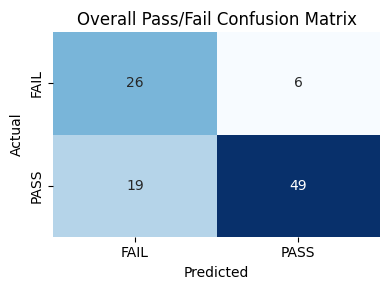

In [ ]:
overall_true, overall_pred = [], []

for r in results:
    # Ground truth overall: PASS only if all checks pass
    gt_overall = all(v for k, v in r['ground_truth'].items() if k not in WARNING_CHECKS)
    # Predicted overall: PASS only if checker passed all checks that have ground truth
    pred_overall = all(
        r['predicted'].get(k, True)
        for k in r['ground_truth'].keys()
    )
    overall_true.append(int(gt_overall))
    overall_pred.append(int(pred_overall))

print('Overall Pass/Fail')
print(classification_report(
    overall_true, overall_pred,
    target_names=['FAIL', 'PASS'],
    zero_division=0,
))

cm_overall = confusion_matrix(overall_true, overall_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_overall, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['FAIL', 'PASS'], yticklabels=['FAIL', 'PASS'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Overall Pass/Fail Confusion Matrix')
plt.tight_layout()
plt.show()

## Metrics by Post Type

This breaks down the overall verdict accuracy by post type. It answers the question: does the checker perform equally well across all post types, or is it weaker for certain types?

Common reasons a post type scores lower:
- Fewer examples of that type in the test set (unreliable metrics due to small sample)
- That type has more conditional checks (more chances for any one check to be wrong)
- The thresholds for that type are not well calibrated (readability threshold too strict or too lenient)

The `n` column shows how many test images you have for each type — if n is below 10 for any type, those metrics are not reliable enough to draw conclusions from.

In [15]:
by_type = defaultdict(lambda: {'y_true': [], 'y_pred': []})

for r in results:
    ptype        = r['post_type']
    gt_overall   = all(r['ground_truth'].values())
    pred_overall = all(r['predicted'].get(k, True) for k in r['ground_truth'].keys())
    by_type[ptype]['y_true'].append(int(gt_overall))
    by_type[ptype]['y_pred'].append(int(pred_overall))

type_rows = []
for ptype, data in sorted(by_type.items()):
    yt, yp = data['y_true'], data['y_pred']
    n   = len(yt)
    acc = sum(t == p for t, p in zip(yt, yp)) / n
    p   = precision_score(yt, yp, zero_division=0)
    r   = recall_score(yt, yp, zero_division=0)
    f1  = f1_score(yt, yp, zero_division=0)
    type_rows.append({'post_type': ptype, 'n': n, 'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1})

df_types = pd.DataFrame(type_rows).set_index('post_type')
display(df_types.style
    .format({'accuracy': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'})
    .background_gradient(subset=['accuracy', 'f1'], cmap='RdYlGn', vmin=0, vmax=1)
)

,n,accuracy,precision,recall,f1
post_type,,,,,
advisory,3,1.000,1.000,1.000,1.000
hiring,2,1.000,1.000,1.000,1.000
holiday,14,0.714,1.000,0.500,0.667
news,17,0.529,0.875,0.500,0.636
other,38,0.789,0.889,0.727,0.800
photo,24,0.833,0.895,0.895,0.895
quote,2,0.500,0.500,1.000,0.667


## Spelling Check

In [16]:
if 'spelling' in by_check:
    sp = by_check['spelling']
    print(f'Spelling check — n={len(sp["y_true"])} images')
    print(classification_report(sp['y_true'], sp['y_pred'],
                                 labels=[0,1], target_names=['HAS ERRORS', 'CLEAN'],
                                 zero_division=0))

    # Show all images where spelling check disagreed with ground truth
    spell_disagreements = [
        r for r in results
        if 'spelling' in r['ground_truth'] and 'spelling' in r['predicted']
        and r['ground_truth']['spelling'] != r['predicted']['spelling']
    ]
    if spell_disagreements:
        print(f'\nSpelling disagreements ({len(spell_disagreements)} images):')
        for r in spell_disagreements:
            gt  = r['ground_truth']['spelling']
            pr  = r['predicted']['spelling']
            err = r['audit_raw'].get('spelling', {}).get('details', {}).get('errors', [])
            flagged = [e['word'] for e in err]
            kind = 'FP (false alarm)' if pr and not gt else 'FN (missed error)'
            print(f"  [{kind}] {r['image']} — flagged: {flagged} | notes: {r['notes']}")
    else:
        print('No spelling disagreements.')
else:
    print('No spelling check data in results (check your labels or post types).')


Spelling check — n=3 images
              precision    recall  f1-score   support

  HAS ERRORS       0.33      1.00      0.50         1
       CLEAN       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3


Spelling disagreements (2 images):
  [FN (missed error)] test_104.jpg — flagged: ['Undas', 'OXd'] | notes: 
  [FN (missed error)] test_106.jpg — flagged: ['NC', 'CADY'] | notes: 


## Pipeline Timing

These cells measure how long `generate_report()` takes per image (YOLO detection is excluded — it runs before the timer starts).

**What the timing statistics mean:**
- **Mean** — the average time across all images. Use this for planning throughput.
- **Median** — the middle value. More robust than mean if a few slow images are skewing the average.
- **P95** — 95th percentile. 95% of images complete within this time. This is the number to use for worst-case planning since it ignores the extreme outliers.
- **Max** — the single slowest image. Usually an outlier caused by a very high-res image or a particularly complex OCR pass.

The histogram shows the shape of the distribution — you want a tight cluster near the left. A long tail to the right means some images are significantly slower and worth investigating.

The boxplot by post type shows whether certain post types are consistently slower. Photo and advisory posts tend to be slower because photo_quality and SGD add extra computation.

In [14]:
times = [r['elapsed_s'] for r in results]

print(f'Mean   : {np.mean(times):.3f}s')
print(f'Median : {np.median(times):.3f}s')
print(f'P95    : {np.percentile(times, 95):.3f}s')
print(f'Max    : {np.max(times):.3f}s')
print(f'Min    : {np.min(times):.3f}s')

Mean   : 8.195s
Median : 5.179s
P95    : 24.302s
Max    : 35.698s
Min    : 2.794s


C:\Users\user\AppData\Local\Temp\ipykernel_25816\3931904552.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_t, labels=labels_t)


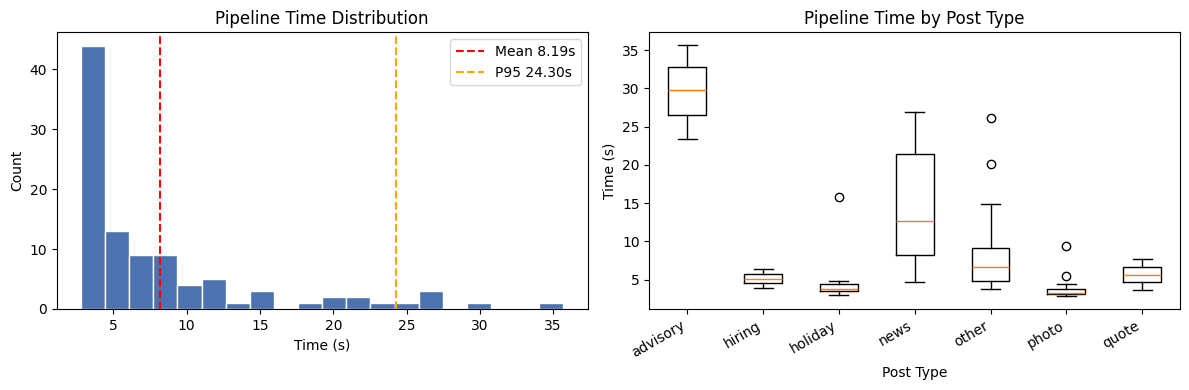

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(times, bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(np.mean(times),           color='red',    linestyle='--', label=f'Mean {np.mean(times):.2f}s')
axes[0].axvline(np.percentile(times, 95), color='orange', linestyle='--', label=f'P95 {np.percentile(times, 95):.2f}s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Pipeline Time Distribution')
axes[0].legend()

type_times = defaultdict(list)
for r in results:
    type_times[r['post_type']].append(r['elapsed_s'])

labels_t = sorted(type_times.keys())
data_t   = [type_times[k] for k in labels_t]
axes[1].boxplot(data_t, labels=labels_t)
axes[1].set_xlabel('Post Type')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Pipeline Time by Post Type')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()



##  Error Analysis

The metrics tell you how often the checker is wrong. This section tells you exactly which images it got wrong and why.

**Disagreement types:**
- `FP` (False Positive): checker said PASS, human said FAIL — checker **missed a real problem**
- `FN` (False Negative): checker said FAIL, human said PASS — checker raised a **false alarm**

The breakdown table groups disagreements by check and error type. The image viewer at the bottom lets you inspect the actual failing images — change `check_filter` and `error_type_filter` to drill into specific checks.

In [ ]:
disagreements = []

for r in results:
    for check, true_val in r['ground_truth'].items():
        if true_val is None:          
            continue
        if check not in r['predicted']:
            continue
        pred_val = r['predicted'][check]
        if pred_val != true_val:
            error_type = 'FP' if pred_val and not true_val else 'FN'
            level = 'warning' if check in WARNING_CHECKS else 'error'
            disagreements.append({
                'image':      r['image'],
                'post_type':  r['post_type'],
                'check':      check,
                'level':      level,
                'error_type': error_type,
                'truth':      true_val,
                'predicted':  pred_val,
                'notes':      r['notes'],
            })

df_errors = pd.DataFrame(disagreements)
print(f'Total disagreements: {len(df_errors)}')

if not df_errors.empty:
    print('\nBreakdown by check and error type (FP = missed problem, FN = false alarm):')
    pivot = df_errors.groupby(['check', 'level', 'error_type']).size().unstack(fill_value=0)
    print(pivot.to_string())


Total disagreements: 50

Breakdown by check and error type (FP = missed problem, FN = false alarm):
error_type              FN  FP
check          level          
logo_bp        error     1   3
logo_nyc       error     3   0
logo_order     error     8   2
logo_sk        error     3   2
logo_yorp      error     1   2
photo_quality  warning   1   2
pubmat_quality error     7   0
readability    error     0   1
spelling       warning   2   0
watermark      error    11   1


In [19]:
# Full table of every disagreement
if not df_errors.empty:
    display(df_errors.sort_values(['level', 'check', 'error_type']))


,image,post_type,check,level,error_type,truth,predicted,notes
17,test_44.jpg,photo,logo_bp,error,FN,True,False,
4,test_15.png,other,logo_bp,error,FP,False,True,Watermark Missing
8,test_16.png,other,logo_bp,error,FP,False,True,
30,test_72.png,other,logo_bp,error,FP,False,True,Watermark missing. Incorrect SK BP YORP logos
10,test_30.jpg,news,logo_nyc,error,FN,True,False,BP logo not present. Logo order invalid. Water...
13,test_41.jpg,photo,logo_nyc,error,FN,True,False,.
16,test_44.jpg,photo,logo_nyc,error,FN,True,False,
0,test_1.jpg,other,logo_order,error,FN,True,False,Watermark Missing
1,test_3.png,other,logo_order,error,FN,True,False,
11,test_33.jpg,other,logo_order,error,FN,True,False,No Logos


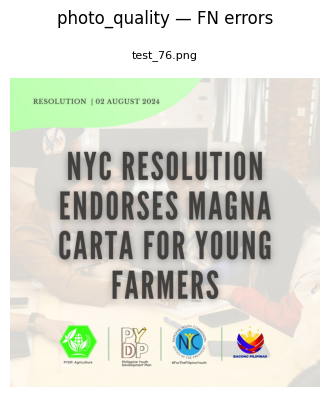

In [26]:
# Display actual images where errors occurred
# Change these two values to inspect a different check or error type
check_filter      = 'photo_quality'   # any check name from the table above
error_type_filter = 'FN'        # 'FP' (missed problem) or 'FN' (false alarm)

subset = df_errors[
    (df_errors['check'] == check_filter) &
    (df_errors['error_type'] == error_type_filter)
]

if subset.empty:
    print(f'No {error_type_filter} errors for "{check_filter}"')
else:
    n = min(len(subset), 6)
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 4))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, subset.head(n).iterrows()):
        img = cv2.imread(os.path.join(TEST_SET_DIR, row['image']))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['image']}\n{row['notes']}", fontsize=8, wrap=True)
        ax.axis('off')
    plt.suptitle(f'{check_filter} — {error_type_filter} errors', fontsize=12)
    plt.tight_layout()
    plt.show()


## Save Results to CSV

This cell flattens everything into a single table and saves it as `eval_results.csv`.

Each row is one image. Columns are prefixed:
- `gt_` columns are the human ground truth values
- `pred_` columns are the checker's predictions
- `elapsed_s` is how long the checker took for that image


In [ ]:
flat_rows = []
for r in results:
    row = {
        'image':     r['image'],
        'post_type': r['post_type'],
        'elapsed_s': r['elapsed_s'],
        'notes':     r['notes'],
    }
    for check, val in r['ground_truth'].items():
        row[f'gt_{check}'] = val
    for check, val in r['predicted'].items():
        row[f'pred_{check}'] = val
    flat_rows.append(row)

df_results = pd.DataFrame(flat_rows)
df_results.to_csv('eval_results.csv', index=False)
print(f'Saved {len(df_results)} rows to eval_results.csv')
display(df_results.head())
